In [2]:
import model
import epidemic_simulation
import survey_design
import random
import numpy as np
import scipy.stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import arviz
import cmdstanpy
from cmdstanpy import CmdStanModel

In [19]:
combined_scores = np.load('combined_scores.npy')
overlapping_scores = np.load('overlapping_scores.npy')
rolling_scores = np.load('rolling_scores.npy')

rolling_scores_low = np.load('rolling_scores_low.npy')

rolling_scores_low2 = np.load('rolling_scores_low_2.npy')

In [20]:
rolling_scores_all = np.vstack((rolling_scores_low, rolling_scores_low2))

rolling_scores_all.shape

(10, 16)

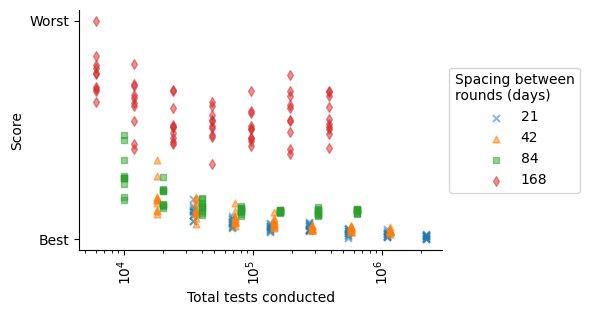

In [18]:
spacings = [21, 42, 84, 168]
sample_sizes = [1000, 2000, 4000, 8000, 16000, 32000, 64000]
full_spacings = np.repeat(spacings, len(sample_sizes))
full_sample_sizes = np.tile(sample_sizes, len(spacings))
m = model.AgentModel(1000000, 50)

fig = plt.figure(figsize=(6, 3.25))

ax = fig.add_subplot(1, 1, 1)

colors = {21: 'tab:blue', 42: 'tab:orange', 84: 'tab:green', 168: 'tab:red'}

markers = {21: 'x', 42: '^', 84: 's', 168: 'd'}

sample_sizes_to_consider = {21: (0, -1), 42: (1, None), 84: (2, None)}
scores_plotted = []

for j, spacing in enumerate(spacings):
    spacing_scores = combined_scores[:, np.where(full_spacings == spacing)]
    mid = np.median(spacing_scores, axis=0)[0]

    for i, sample_size in enumerate(sample_sizes):
        surveys = survey_design.make_surveys(m, [spacing], [sample_size], [spacing], [sample_size], duration=7)
        effort = surveys[0].sample_size * len(surveys[0].start_dates) + surveys[1].sample_size * len(surveys[1].start_dates)

        for k in range(spacing_scores.shape[0]):
            ax.scatter([effort,], [spacing_scores[k, 0, i],], marker=markers[spacing], color=colors[spacing], s=25, label=spacing if k == 0 and i == 0 else None, alpha=0.5)
            scores_plotted.append(spacing_scores[k, 0, i])


ax.legend(title='Spacing between\nrounds (days)', loc='center left', bbox_to_anchor=(1, 0.5))

yticks = [np.min(scores_plotted), np.max(scores_plotted)]
ax.set_yticks(yticks)
ax.set_yticklabels(['Best', 'Worst'])

ax.spines[['right', 'top']].set_visible(False)
ax.set_xlabel('Total tests conducted')
ax.set_ylabel('Score')

ax.set_xscale('log')
plt.xticks(rotation=90, ha='center')

fig.set_tight_layout(True)

plt.show()

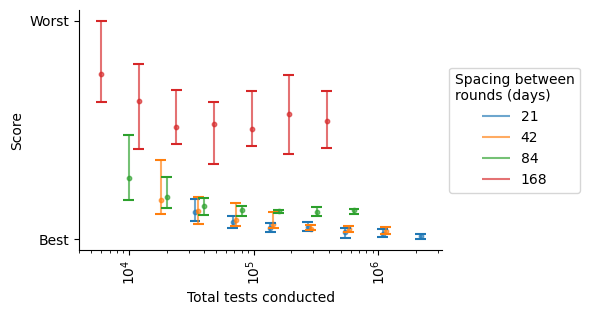

In [4]:
spacings = [21, 42, 84, 168]
sample_sizes = [1000, 2000, 4000, 8000, 16000, 32000, 64000]
full_spacings = np.repeat(spacings, len(sample_sizes))
full_sample_sizes = np.tile(sample_sizes, len(spacings))
m = model.AgentModel(1000000, 50)

fig = plt.figure(figsize=(6, 3.25))

ax = fig.add_subplot(1, 1, 1)

colors = {21: 'tab:blue', 42: 'tab:orange', 84: 'tab:green', 168: 'tab:red'}

markers = {21: 'x', 42: '^', 84: 's', 168: 'd'}

sample_sizes_to_consider = {21: (0, -1), 42: (1, None), 84: (2, None)}
scores_plotted = []

for j, spacing in enumerate(spacings):
    spacing_scores = combined_scores[:, np.where(full_spacings == spacing)]
    mid = np.median(spacing_scores, axis=0)[0]

    for i, sample_size in enumerate(sample_sizes):
        surveys = survey_design.make_surveys(m, [spacing], [sample_size], [spacing], [sample_size], duration=7)
        effort = surveys[0].sample_size * len(surveys[0].start_dates) + surveys[1].sample_size * len(surveys[1].start_dates)

        x = []        
        for k in range(spacing_scores.shape[0]):
            x.append(spacing_scores[k, 0, i])
        # widths = effort * 0.2

        ax.vlines(effort, min(x), max(x), color=colors[spacing], alpha=0.65, label=spacing if i == 0 else None)
        ax.hlines(min(x), effort*0.9, effort*1.1, color=colors[spacing])
        ax.hlines(max(x), effort*0.9, effort*1.1, color=colors[spacing])
        ax.scatter([effort,], [np.median(x),], color=colors[spacing], s=10, alpha=0.65)
        
        # b = ax.boxplot(x, positions=[effort,], widths=1, patch_artist=True, showfliers=False, showmeans=False,
        #                medianprops={'lw': 0}, whiskerprops={'color': colors[spacing]}, capprops={'color': colors[spacing]})
        # b['boxes'][0].set_facecolor(colors[spacing])
        # b['boxes'][0].set_alpha(0.75)
        # b['boxes'][0].set_edgecolor(colors[spacing])

        # ax.scatter([effort,], [spacing_scores[k, 0, i],], marker=markers[spacing], color=colors[spacing], s=25, label=spacing if k == 0 and i == 0 else None, alpha=0.5)
        scores_plotted += list(x)


ax.legend(title='Spacing between\nrounds (days)', loc='center left', bbox_to_anchor=(1, 0.5))

yticks = [np.min(scores_plotted), np.max(scores_plotted)]
ax.set_yticks(yticks)
ax.set_yticklabels(['Best', 'Worst'])

ax.spines[['right', 'top']].set_visible(False)
ax.set_xlabel('Total tests conducted')
ax.set_ylabel('Score')

ax.set_xscale('log')
plt.xticks(rotation=90, ha='center')

fig.set_tight_layout(True)

plt.savefig('Figure4b.pdf')

plt.show()

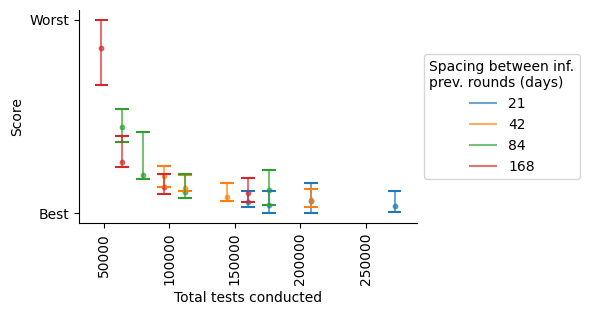

In [11]:
sample_size = 8000
spacings = [21, 42, 84, 168]
full_sample_sizes = np.repeat(sample_size, len(spacings)**2)
prev_spacings = np.repeat(spacings, len(spacings))
sero_spacings = np.tile(spacings, len(spacings))

fig = plt.figure(figsize=(6, 3.25))

ax = fig.add_subplot(1, 1, 1)

colors = {21: 'tab:blue', 42: 'tab:orange', 84: 'tab:green', 168: 'tab:red'}

sample_sizes_to_consider = {21: (0, -1), 42: (1, None), 84: (2, None)}
scores_plotted = []

for j, prev_spacing in enumerate(spacings):
    spacing_scores = overlapping_scores[:, np.where(prev_spacings == prev_spacing)]
    mid = np.median(spacing_scores, axis=0)[0]

    # spacing_scores = all_scores[1, np.where(full_spacings == spacing)]
    # mid = np.mean(spacing_scores, axis=0)

    # s0, s1 = sample_sizes_to_consider[spacing]
    # mid = mid[s0:s1]
    # for i, sample_size in enumerate(sample_sizes[s0:s1]):
    for i, sero_spacing in enumerate(spacings):
        surveys = survey_design.make_surveys(m, [prev_spacing], [sample_size], [sero_spacing], [sample_size], duration=7)
        effort = surveys[0].sample_size * len(surveys[0].start_dates) + surveys[1].sample_size * len(surveys[1].start_dates)

        # ax.scatter([effort,], [mid[i],], color=colors[spacing], s=50, label=spacing if i == 0 else None)
        x = []
        for k in range(spacing_scores.shape[0]):
            x.append(spacing_scores[k, 0, i])
            # ax.scatter([effort,], [spacing_scores[k, 0, i],], color=colors[prev_spacing], s=25, label=prev_spacing if k == 0 and i == 0 else None, alpha=0.5)
            # scores_plotted.append(spacing_scores[k, 0, i])

        ax.vlines(effort, min(x), max(x), color=colors[prev_spacing], alpha=0.65, label=prev_spacing if i == 0 else None)
        wl = 5000
        ax.hlines(min(x), effort - wl, effort + wl, color=colors[prev_spacing])
        ax.hlines(max(x), effort - wl, effort + wl, color=colors[prev_spacing])
        ax.scatter([effort,], [np.median(x),], color=colors[prev_spacing], s=10, alpha=0.65)
        scores_plotted += list(x)


ax.legend(title='Spacing between inf.\nprev. rounds (days)', loc='center left', bbox_to_anchor=(1, 0.5))

yticks = [np.min(scores_plotted), np.max(scores_plotted)]
ax.set_yticks(yticks)
ax.set_yticklabels(['Best', 'Worst'])

ax.spines[['right', 'top']].set_visible(False)
ax.set_xlabel('Total tests conducted')
ax.set_ylabel('Score')

# ax.set_xscale('log')
# ax.set_yscale('log')

# ax.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=90, ha='center')

fig.set_tight_layout(True)

plt.savefig('Figure5b.pdf')

# ax.set_ylim(500, 17000)

plt.show()

In [49]:
rolling_scores_all.shape

(10, 16)

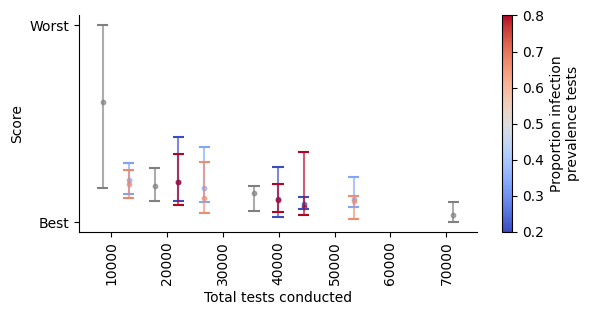

In [52]:
# sample_sizes = [100, 200, 400, 800,]
sample_sizes = [12, 25, 50, 100,] 
prev_sample_sizes = np.repeat(sample_sizes, len(sample_sizes))
sero_sample_sizes = np.tile(sample_sizes, len(sample_sizes))
spacings = [1] * len(prev_sample_sizes)


fig = plt.figure(figsize=(6, 3.25))

ax = fig.add_subplot(1, 1, 1)

colors = {100: 'tab:blue', 200: 'tab:orange', 400: 'tab:green', 800: 'tab:red'}

cmap = matplotlib.colormaps['coolwarm']

sample_sizes_to_consider = {21: (0, -1), 42: (1, None), 84: (2, None)}
scores_plotted = []

for j, prev_ss in enumerate(sample_sizes):
    spacing_scores = np.asarray(rolling_scores_all)[:, np.where(prev_sample_sizes == prev_ss)]
    mid = np.median(spacing_scores, axis=0)[0]


    for i, sero_ss in enumerate(sample_sizes):
        surveys = survey_design.make_surveys(m, [1], [prev_ss], [1], [sero_ss], duration=7)
        effort = surveys[0].sample_size * len(surveys[0].start_dates) + surveys[1].sample_size * len(surveys[1].start_dates)

        ratio = prev_ss / (prev_ss + sero_ss)
        x = []
        for k in range(spacing_scores.shape[0]):
            x.append(spacing_scores[k, 0, i])
            # ax.scatter([effort,], [spacing_scores[k, 0, i],], s=30, color='none', ec='k', lw=0.5, alpha=1, zorder=1)
            # norm = matplotlib.colors.Normalize(vmin=0.2, vmax=0.8)
            # z = norm(ratio)
            # ax.scatter([effort,], [spacing_scores[k, 0, i],], ec='none', color=cmap(z), s=30, label=prev_ss if k == 0 and i == 0 else None, alpha=0.5, zorder=1)
            # scores_plotted.append(spacing_scores[k, 0, i])
        
        norm = matplotlib.colors.Normalize(vmin=0.2, vmax=0.8)
        z = norm(ratio)
        if abs(z - 0.5) < 1e-3:
            color = 'gray'
        else:
            color = cmap(z)

        wl = 1e3
        ax.vlines(effort, min(x), max(x), color=color, alpha=0.65, label=spacing if i == 0 else None)
        ax.hlines(min(x), effort - wl, effort + wl, color=color)
        ax.hlines(max(x), effort - wl, effort + wl, color=color)
        ax.scatter([effort,], [np.median(x),], color=color, s=10, alpha=0.65)

        scores_plotted += x


# ax.legend(title='Inf. prev. samples\nper day', loc='center left', bbox_to_anchor=(1, 0.5))
# norm = matplotlib.colors.Normalize(vmin=0, vmax=1, clip=False)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Proportion infection\nprevalence tests')

yticks = [np.min(scores_plotted), np.max(scores_plotted)]
ax.set_yticks(yticks)
ax.set_yticklabels(['Best', 'Worst'])

ax.spines[['right', 'top']].set_visible(False)
ax.set_xlabel('Total tests conducted')
ax.set_ylabel('Score')

plt.xticks(rotation=90, ha='center')

fig.set_tight_layout(True)

plt.savefig('Figure6b.pdf')

plt.show()

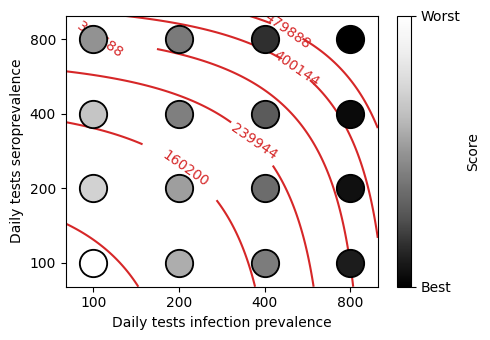

In [29]:
avg_scores = np.mean(rolling_scores, axis=0)

fig = plt.figure(figsize=(5, 3.5))
ax = fig.add_subplot(1, 1, 1)

dense_ss_prev = np.arange(80, 1000, 2)
dense_ss_sero = np.arange(80, 1000, 2)

X, Y = np.meshgrid(dense_ss_prev, dense_ss_sero)

effort = np.zeros(X.shape)
for i, prev_ss in enumerate(dense_ss_prev):
    for j, sero_ss in enumerate(dense_ss_sero):
        surveys = survey_design.make_surveys(m, [1], [prev_ss], [1], [sero_ss])
        effort[j, i] = surveys[0].sample_size * len(surveys[0].start_dates) + surveys[1].sample_size * len(surveys[1].start_dates)

levels = [80000, 160000, 240000, 320000, 400000, 480000]

true_levels = []
for l in levels:
    nearest = min(effort.flatten(), key=lambda x:abs(x-l))
    true_levels.append(nearest)

cs = ax.contour(X, Y, effort, true_levels, colors='tab:red', zorder=-10,)
ax.clabel(cs, cs.levels, fontsize=10)


cmap = mpl.colormaps['Greys_r']

highest_crps = max(avg_scores)
lowest_crps = min(avg_scores)

for score, prev_sample_size, sero_sample_size in zip(avg_scores, prev_sample_sizes, sero_sample_sizes):
    color = cmap((score - lowest_crps) / (highest_crps - lowest_crps))
    ax.scatter([prev_sample_size,], [sero_sample_size,], color=color, zorder=-1, s=300)
    ax.scatter([prev_sample_size,], [sero_sample_size,], color='k', zorder=-2, alpha=1, s=400)
    # ax.text(prev_sample_size, sero_sample_size, '{:.2f}'.format(score), color='red', zorder=100, ha='left')

cbar = plt.colorbar(cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=lowest_crps, vmax=highest_crps), cmap=cmap), ax=ax, label='Score')
cbar.set_ticks([lowest_crps, highest_crps])
cbar.set_ticklabels(['Best', 'Worst'])

ax.set_xlabel('Daily tests infection prevalence')
ax.set_ylabel('Daily tests seroprevalence')

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xticks(sample_sizes)
ax.set_yticks(sample_sizes)
ax.set_xticklabels(sample_sizes)
ax.set_yticklabels(sample_sizes)

ax.set_xticks([], minor=True)
ax.set_yticks([], minor=True)

fig.set_tight_layout(True)

plt.savefig('Figure6a.pdf')

plt.show()


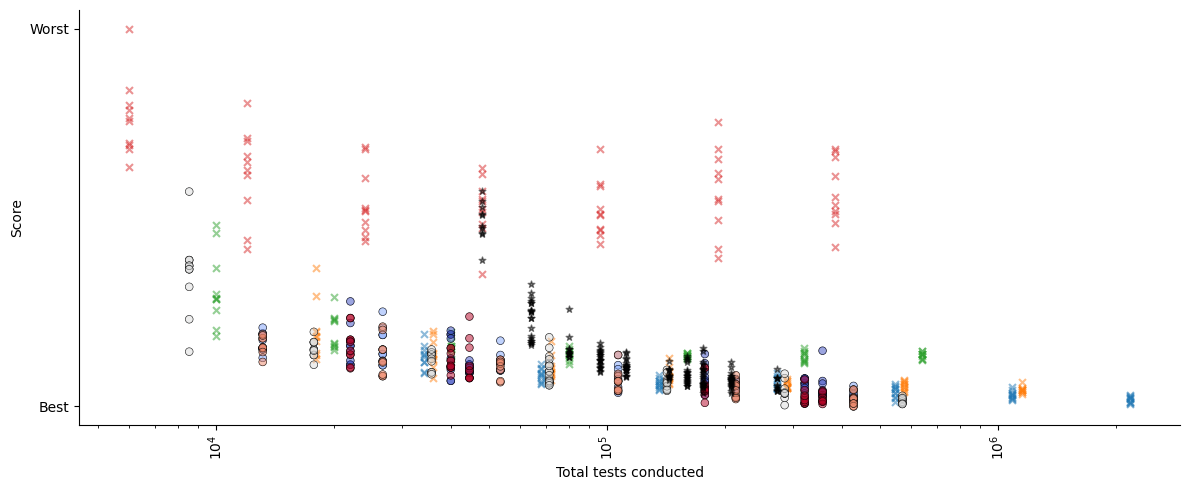

In [46]:
spacings = [21, 42, 84, 168]
sample_sizes = [1000, 2000, 4000, 8000, 16000, 32000, 64000]
full_spacings = np.repeat(spacings, len(sample_sizes))
full_sample_sizes = np.tile(sample_sizes, len(spacings))
m = model.AgentModel(1000000, 50)

fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(1, 1, 1)

colors = {21: 'tab:blue', 42: 'tab:orange', 84: 'tab:green', 168: 'tab:red'}


sample_sizes_to_consider = {21: (0, -1), 42: (1, None), 84: (2, None)}
scores_plotted = []

for j, spacing in enumerate(spacings):
    spacing_scores = combined_scores[:, np.where(full_spacings == spacing)]
    mid = np.median(spacing_scores, axis=0)[0]

    for i, sample_size in enumerate(sample_sizes):
        surveys = survey_design.make_surveys(m, [spacing], [sample_size], [spacing], [sample_size], duration=7)
        effort = surveys[0].sample_size * len(surveys[0].start_dates) + surveys[1].sample_size * len(surveys[1].start_dates)

        for k in range(spacing_scores.shape[0]):
            ax.scatter([effort,], [spacing_scores[k, 0, i],], marker='x', color=colors[spacing], s=25, label=spacing if k == 0 and i == 0 else None, alpha=0.5)
            scores_plotted.append(spacing_scores[k, 0, i])


sample_sizes = [100, 200, 400, 800,]
prev_sample_sizes = np.repeat(sample_sizes, len(sample_sizes))
sero_sample_sizes = np.tile(sample_sizes, len(sample_sizes))
spacings = [1] * len(prev_sample_sizes)

for j, prev_ss in enumerate(sample_sizes):
    spacing_scores = np.asarray(rolling_scores)[:, np.where(prev_sample_sizes == prev_ss)]
    mid = np.median(spacing_scores, axis=0)[0]

    for i, sero_ss in enumerate(sample_sizes):
        surveys = survey_design.make_surveys(m, [1], [prev_ss], [1], [sero_ss], duration=7)
        effort = surveys[0].sample_size * len(surveys[0].start_dates) + surveys[1].sample_size * len(surveys[1].start_dates)

        ratio = prev_ss / (prev_ss + sero_ss)
        for k in range(spacing_scores.shape[0]):
            ax.scatter([effort,], [spacing_scores[k, 0, i],], s=30, color='none', ec='k', lw=0.5, alpha=1, zorder=1)
            norm = matplotlib.colors.Normalize(vmin=0.2, vmax=0.8)
            z = norm(ratio)
            ax.scatter([effort,], [spacing_scores[k, 0, i],], ec='none', color=cmap(z), s=30, label=prev_ss if k == 0 and i == 0 else None, alpha=0.5, zorder=1)
            scores_plotted.append(spacing_scores[k, 0, i])


sample_sizes = [12, 25, 50, 100,]
prev_sample_sizes = np.repeat(sample_sizes, len(sample_sizes))
sero_sample_sizes = np.tile(sample_sizes, len(sample_sizes))
spacings = [1] * len(prev_sample_sizes)

for j, prev_ss in enumerate(sample_sizes):
    spacing_scores = np.asarray(rolling_scores_all)[:, np.where(prev_sample_sizes == prev_ss)]
    mid = np.median(spacing_scores, axis=0)[0]

    for i, sero_ss in enumerate(sample_sizes):
        surveys = survey_design.make_surveys(m, [1], [prev_ss], [1], [sero_ss], duration=7)
        effort = surveys[0].sample_size * len(surveys[0].start_dates) + surveys[1].sample_size * len(surveys[1].start_dates)

        ratio = prev_ss / (prev_ss + sero_ss)
        for k in range(spacing_scores.shape[0]):
            ax.scatter([effort,], [spacing_scores[k, 0, i],], s=30, color='none', ec='k', lw=0.5, alpha=1, zorder=1)
            norm = matplotlib.colors.Normalize(vmin=0.2, vmax=0.8)
            z = norm(ratio)
            ax.scatter([effort,], [spacing_scores[k, 0, i],], ec='none', color=cmap(z), s=30, label=prev_ss if k == 0 and i == 0 else None, alpha=0.5, zorder=1)
            scores_plotted.append(spacing_scores[k, 0, i])

            


colors = {21: 'tab:blue', 42: 'tab:orange', 84: 'tab:green', 168: 'tab:red'}
sample_sizes_to_consider = {21: (0, -1), 42: (1, None), 84: (2, None)}
sample_size = 8000
spacings = [21, 42, 84, 168]
full_sample_sizes = np.repeat(sample_size, len(spacings)**2)
prev_spacings = np.repeat(spacings, len(spacings))
sero_spacings = np.tile(spacings, len(spacings))


for j, prev_spacing in enumerate(spacings):
    spacing_scores = overlapping_scores[:, np.where(prev_spacings == prev_spacing)]
    mid = np.median(spacing_scores, axis=0)[0]
    for i, sero_spacing in enumerate(spacings):
        surveys = survey_design.make_surveys(m, [prev_spacing], [sample_size], [sero_spacing], [sample_size], duration=7)
        effort = surveys[0].sample_size * len(surveys[0].start_dates) + surveys[1].sample_size * len(surveys[1].start_dates)

        for k in range(spacing_scores.shape[0]):
            ax.scatter([effort,], [spacing_scores[k, 0, i],], marker='*', color='k', s=25, label=prev_spacing if k == 0 and i == 0 else None, alpha=0.5)
            scores_plotted.append(spacing_scores[k, 0, i])

yticks = [np.min(scores_plotted), np.max(scores_plotted)]
ax.set_yticks(yticks)
ax.set_yticklabels(['Best', 'Worst'])

ax.spines[['right', 'top']].set_visible(False)
ax.set_xlabel('Total tests conducted')
ax.set_ylabel('Score')

ax.set_xscale('log')
plt.xticks(rotation=90, ha='center')

fig.set_tight_layout(True)

plt.show()

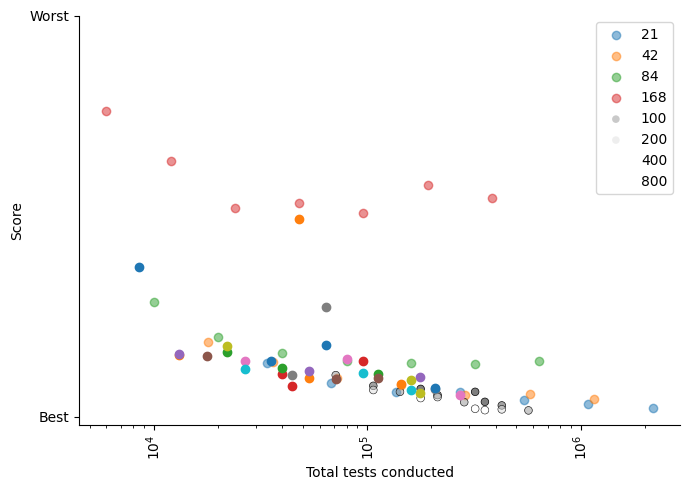

In [ ]:
spacings = [21, 42, 84, 168]
sample_sizes = [1000, 2000, 4000, 8000, 16000, 32000, 64000]
full_spacings = np.repeat(spacings, len(sample_sizes))
full_sample_sizes = np.tile(sample_sizes, len(spacings))
m = model.AgentModel(1000000, 50)

fig = plt.figure(figsize=(7, 5))

ax = fig.add_subplot(1, 1, 1)

colors = {21: 'tab:blue', 42: 'tab:orange', 84: 'tab:green', 168: 'tab:red'}


sample_sizes_to_consider = {21: (0, -1), 42: (1, None), 84: (2, None)}
scores_plotted = []

for j, spacing in enumerate(spacings):
    spacing_scores = combined_scores[:, np.where(full_spacings == spacing)]
    mid = np.median(spacing_scores, axis=0)[0]

    for i, sample_size in enumerate(sample_sizes):
        surveys = survey_design.make_surveys(m, [spacing], [sample_size], [spacing], [sample_size], duration=7)
        effort = surveys[0].sample_size * len(surveys[0].start_dates) + surveys[1].sample_size * len(surveys[1].start_dates)

        x = []
        for k in range(spacing_scores.shape[0]):
            x.append(spacing_scores[k, 0, i])
            # ax.scatter([effort,], [spacing_scores[k, 0, i],], marker='x', color=colors[spacing], s=25, label=spacing if k == 0 and i == 0 else None, alpha=0.5)
            scores_plotted.append(spacing_scores[k, 0, i])
        ax.scatter([effort,], np.median(x), color=colors[spacing], label=spacing if i == 0 else None, alpha=0.5)


sample_sizes = [100, 200, 400, 800,]
prev_sample_sizes = np.repeat(sample_sizes, len(sample_sizes))
sero_sample_sizes = np.tile(sample_sizes, len(sample_sizes))
spacings = [1] * len(prev_sample_sizes)

for j, prev_ss in enumerate(sample_sizes):
    spacing_scores = np.asarray(rolling_scores)[:, np.where(prev_sample_sizes == prev_ss)]
    mid = np.median(spacing_scores, axis=0)[0]

    for i, sero_ss in enumerate(sample_sizes):
        surveys = survey_design.make_surveys(m, [1], [prev_ss], [1], [sero_ss], duration=7)
        effort = surveys[0].sample_size * len(surveys[0].start_dates) + surveys[1].sample_size * len(surveys[1].start_dates)

        ratio = prev_ss / (prev_ss + sero_ss)
        x = []
        for k in range(spacing_scores.shape[0]):
            x.append(spacing_scores[k, 0, i],)
            # ax.scatter([effort,], [spacing_scores[k, 0, i],], s=30, color='none', ec='k', lw=0.5, alpha=1, zorder=1)
            norm = matplotlib.colors.Normalize(vmin=0.2, vmax=0.8)
            z = norm(ratio)
            # ax.scatter([effort,], [spacing_scores[k, 0, i],], ec='none', color=cmap(z), s=30, label=prev_ss if k == 0 and i == 0 else None, alpha=0.5, zorder=1)
            scores_plotted.append(spacing_scores[k, 0, i])

        ax.scatter([effort,], np.median(x), s=30, color='none', ec='k', lw=0.5, alpha=1, zorder=1)
        ax.scatter([effort,], np.median(x), ec='none', color=cmap(z), s=30, label=prev_ss if i == 0 else None, alpha=0.5, zorder=1)



sample_sizes = [12, 25, 50, 100,]
prev_sample_sizes = np.repeat(sample_sizes, len(sample_sizes))
sero_sample_sizes = np.tile(sample_sizes, len(sample_sizes))
spacings = [1] * len(prev_sample_sizes)

for j, prev_ss in enumerate(sample_sizes):
    spacing_scores = np.asarray(rolling_scores_low)[:, np.where(prev_sample_sizes == prev_ss)]
    mid = np.median(spacing_scores, axis=0)[0]

    for i, sero_ss in enumerate(sample_sizes):
        surveys = survey_design.make_surveys(m, [1], [prev_ss], [1], [sero_ss], duration=7)
        effort = surveys[0].sample_size * len(surveys[0].start_dates) + surveys[1].sample_size * len(surveys[1].start_dates)

        ratio = prev_ss / (prev_ss + sero_ss)
        x = []
        for k in range(spacing_scores.shape[0]):
            x.append(spacing_scores[k, 0, i])
            # ax.scatter([effort,], [spacing_scores[k, 0, i],], s=30, color='none', ec='k', lw=0.5, alpha=1, zorder=1)
            # norm = matplotlib.colors.Normalize(vmin=0.2, vmax=0.8)
            # z = norm(ratio)
            # ax.scatter([effort,], [spacing_scores[k, 0, i],], ec='none', color=cmap(z), s=30, label=prev_ss if k == 0 and i == 0 else None, alpha=0.5, zorder=1)
            scores_plotted.append(spacing_scores[k, 0, i])

        ax.scatter([effort,], np.median(x))

            


colors = {21: 'tab:blue', 42: 'tab:orange', 84: 'tab:green', 168: 'tab:red'}
sample_sizes_to_consider = {21: (0, -1), 42: (1, None), 84: (2, None)}
sample_size = 8000
spacings = [21, 42, 84, 168]
full_sample_sizes = np.repeat(sample_size, len(spacings)**2)
prev_spacings = np.repeat(spacings, len(spacings))
sero_spacings = np.tile(spacings, len(spacings))


for j, prev_spacing in enumerate(spacings):
    spacing_scores = overlapping_scores[:, np.where(prev_spacings == prev_spacing)]
    mid = np.median(spacing_scores, axis=0)[0]
    for i, sero_spacing in enumerate(spacings):
        surveys = survey_design.make_surveys(m, [prev_spacing], [sample_size], [sero_spacing], [sample_size], duration=7)
        effort = surveys[0].sample_size * len(surveys[0].start_dates) + surveys[1].sample_size * len(surveys[1].start_dates)

        x = []
        for k in range(spacing_scores.shape[0]):
            x.append(spacing_scores[k, 0, i])
            # ax.scatter([effort,], [spacing_scores[k, 0, i],], marker='*', color='k', s=25, label=prev_spacing if k == 0 and i == 0 else None, alpha=0.5)
            scores_plotted.append(spacing_scores[k, 0, i])
        ax.scatter([effort,], np.median(x))

yticks = [np.min(scores_plotted), np.max(scores_plotted)]
ax.set_yticks(yticks)
ax.set_yticklabels(['Best', 'Worst'])

ax.spines[['right', 'top']].set_visible(False)
ax.set_xlabel('Total tests conducted')
ax.set_ylabel('Score')

ax.set_xscale('log')
plt.xticks(rotation=90, ha='center')

fig.set_tight_layout(True)

ax.legend()

plt.show()